# MNIST 次元削減の復元精度・プライバシー攻撃 実験

このノートブックでは、`dimensionality_reduction.py` と `anchor_utils.py` を用いて、
次元削減後の表現から元の特徴量をどの程度復元できるか、および将来的なプライバシー攻撃の実験用の枠組みを用意します。

基本設定は `base_config` で与えられた MNIST 用の設定を使用します。


In [93]:
import sys, os
from pathlib import Path
from types import SimpleNamespace

# リポジトリ直下や親ディレクトリから src を探索して import path に追加
cwd = Path.cwd()
candidate_roots = [cwd] + list(cwd.parents)
src_dir = None
for root in candidate_roots:
    cand = root / "src"
    if cand.exists():
        src_dir = cand
        break

if src_dir is None:
    raise RuntimeError(
        "src ディレクトリが見つかりません。"
        "ノートブックの実行ディレクトリをリポジトリ直下にするか、"
        "このセルのパス設定を修正してください。"
    )

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

repo_root = Path.cwd()
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# ★ これを追加 ★
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
    
from pathlib import Path
import sys

repo_root = Path.cwd()
# ここが dca 直下でない場合は親を辿る
if not (repo_root / "src").exists():
    for p in repo_root.parents:
        if (p / "src").exists():
            repo_root = p
            break

# src とリポジトリ直下の両方を sys.path に追加
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))


# モジュールのインポート
from institution_data_pipeline.load_data import LOADERS
import dimensionality_reduction
from intermediate_expression import anchor_utils

print("OK: imported dimensionality_reduction and anchor_utils")
print("src_dir:", src_dir)
print("MNIST loader exists:", "mnist" in LOADERS)

OK: imported dimensionality_reduction and anchor_utils
src_dir: c:\Users\sueya\Git-Repositories\takano_labo\dca\src
MNIST loader exists: True


In [183]:
import numpy as np
import pandas as pd

base_config = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1200,
    "data_distribution": "even",
    "anchor_method": "smote",
    "num_anchor_data": 1200,
    "dim_intermediate": 600,
    "F_type": "svd",
    "seed": 42,
    "inter_normalization": False,
    "spill_num": 100,
}

cfg = SimpleNamespace(**base_config)

# MNIST DataFrame を読み込み
df_full = LOADERS[cfg.dataset]()
print("Full dataset shape:", df_full.shape)

# num_institution_user 行だけサンプリング
rng = np.random.default_rng(cfg.seed)
indices = rng.choice(len(df_full), size=cfg.num_institution_user, replace=False)
df_sub = df_full.iloc[indices].reset_index(drop=True)

y = df_sub[cfg.y_name].to_numpy()
X_raw = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
X = scaler_x.fit_transform(X_raw).astype(np.float32)

X.shape, y.shape


Full dataset shape: (70000, 785)


((1200, 784), (1200,))

In [184]:
# 次元削減の構築と適用
projector = dimensionality_reduction.build_dimensionality_projector(
    X,
    n_components=cfg.dim_intermediate,
    F_type=cfg.F_type,
    seed=int(cfg.seed),
    config=cfg,
)

X_tilde = projector(X)
X_tilde.shape


(1200, 600)

In [185]:
# アンカーデータ A の生成（anchor_utils.produce_anchor を利用）
num_row = cfg.num_anchor_data
num_col = X.shape[1]

anchor_cfg = SimpleNamespace(
    anchor_method=cfg.anchor_method,
    y_name=cfg.y_name,
    smote_ratio=1.0,
)

A = anchor_utils.produce_anchor(
    num_row=num_row,
    num_col=num_col,
    seed=int(cfg.seed),
    config=anchor_cfg,
    train_df=df_sub,
    Xs_train=[X],
    Xs_test=[X],
    ys_train=[y],
    ys_test=[y],
)

# 重要: X と同じ StandardScaler を A にも適用してから投影
A = scaler_x.transform(A).astype(np.float32)

A_tilde = projector(A)

A.shape, A_tilde.shape


((1200, 784), (1200, 600))

In [186]:
# アンカーの一部 A' / A~' が流出したと仮定
spill_num = int(cfg.spill_num)
spill_num = min(spill_num, A.shape[0])

idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)

A_leak = A[idx_leak]
A_tilde_leak = A_tilde[idx_leak]

A_leak.shape, A_tilde_leak.shape


((100, 784), (100, 600))

In [187]:
from sklearn.metrics import mean_squared_error

# 疑似逆行列ベースの f^{-1} の近似
# A~' * W ≈ A' となる W を最小二乗で推定し、x ≈ z W と復元する
Z = A_tilde_leak  # (spill_num, k)
X_target = A_leak  # (spill_num, d)

# lstsq で Z @ W ≈ X_target を解く
W_pinv, *_ = np.linalg.lstsq(Z, X_target, rcond=None)

def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
    return Z_input @ W_pinv

# 元データ X に対する復元
X_rec_pinv = f_inv_pinv(X_tilde)

rmse_pinv = np.sqrt(mean_squared_error(X, X_rec_pinv))
rmse_pinv


0.5851254466135517

In [188]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# MLP による f^{-1} 近似（model.py の MLP 設定を参考）
scaler_z = StandardScaler()
Z_train = scaler_z.fit_transform(A_tilde_leak)

mlp = MLPRegressor(
    hidden_layer_sizes=(256,),
    activation="relu",
    solver="adam",
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=int(cfg.seed),
)

mlp.fit(Z_train, A_leak)

Z_all = scaler_z.transform(X_tilde)
X_rec_mlp = mlp.predict(Z_all)

rmse_mlp = np.sqrt(mean_squared_error(X, X_rec_mlp))
rmse_mlp


17.803308623143213

In [ ]:
import copy
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from src.dimensionality_reduction import build_dimensionality_projector


def _fit_linear_decoder(Z_train: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """Z -> X の最小二乗線形復元行列（疑似逆行列）を求める。"""
    Ztr = np.asarray(Z_train, float)
    Xtr = np.asarray(X_train, float)
    Ztr_aug = np.hstack([Ztr, np.ones((Ztr.shape[0], 1))])
    # lstsq: Ztr_aug @ W ≈ Xtr
    W, *_ = np.linalg.lstsq(Ztr_aug, Xtr, rcond=None)
    return W  # 形状: (d_z+1, d_x)


def _linear_recon_mse(W: np.ndarray, Z: np.ndarray, X_true: np.ndarray) -> float:
    Z_aug = np.hstack([Z, np.ones((Z.shape[0], 1))])
    X_hat = Z_aug @ W
    return float(mean_squared_error(X_true, X_hat))


def _mlp_recon_mse(Z_train, X_train, Z_test, X_test, random_state: int = 0) -> tuple[MLPRegressor, float]:
    reg = MLPRegressor(
        hidden_layer_sizes=(256, 256),
        activation="relu",
        max_iter=200,
        random_state=random_state,
    )
    reg.fit(Z_train, X_train)
    X_hat = reg.predict(Z_test)
    mse = float(mean_squared_error(X_test, X_hat))
    return reg, mse


def run_reconstruction_experiment(
    X_train: np.ndarray,
    X_test: np.ndarray,
    base_config,
) -> dict:
    """
    次元削減表現からの復元性能を測る実験を実行する。

    - base_config.F_type に対する疑似逆行列 + MLP 復元 MSE
    - F_type='svd' のときの疑似逆行列 + MLP 復元 MSE
    を print し，結果を dict で返す。
    """
    results: dict = {}

    def _project_with_config(cfg, F_type: str, name: str):
        cfg.F_type = F_type
        n_components = int(getattr(cfg, "dim_intermediate", getattr(cfg, "dim_integrate", 2)))
        proj = build_dimensionality_projector(
            X=X_train,
            n_components=n_components,
            y=None,
            F_type=F_type,
            seed=getattr(cfg, "f_seed", None),
            config=cfg,
        )
        Z_tr = proj(X_train)
        Z_te = proj(X_test)

        # 疑似逆行列（線形デコーダ）
        W = _fit_linear_decoder(Z_tr, X_train)
        mse_lin = _linear_recon_mse(W, Z_te, X_test)

        # MLP による復元
        mlp, mse_mlp = _mlp_recon_mse(Z_tr, X_train, Z_te, X_test, random_state=getattr(cfg, "seed", 0))

        print(f"[{name}] F_type={F_type}, dim={Z_tr.shape[1]}")
        print(f"  linear pseudo-inverse MSE: {mse_lin:.6f}")
        print(f"  MLP reconstruction MSE   : {mse_mlp:.6f}")

        results[f"{name}_F_type"] = F_type
        results[f"{name}_dim"] = int(Z_tr.shape[1])
        results[f"{name}_linear_decoder"] = W
        results[f"{name}_linear_mse"] = mse_lin
        results[f"{name}_mlp"] = mlp
        results[f"{name}_mlp_mse"] = mse_mlp

    # 1) base_config の F_type
    ftype_base = getattr(base_config, "F_type", "svd")
    _project_with_config(base_config, ftype_base, name="base")

    # 2) 参考: F_type='svd'
    _project_with_config(base_config, "svd", name="svd")

    return results


In [ ]:
results = run_reconstruction_experiment(X_train, X_test, base_config)


## 今後の拡張 (TODO)

- A に対して DP ノイズ（例: ガウス機密保持ノイズ）を付加してから次元削減し，
  上記の f^{-1} による復元精度を比較する。
- Attribute Inference / Membership Inference 攻撃を実装し，
  復元精度とプライバシー攻撃の成功率の関係を評価する。


In [6]:
# ノートブックの最初でリポジトリ直下に移動
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break

os.chdir(repo_root)
print("CWD:", os.getcwd())


CWD: c:\Users\sueya\Git-Repositories\takano_labo\dca


In [14]:
import numpy as np
import pandas as pd
from types import SimpleNamespace
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

from config.config import Config
from src.institution_data_pipeline.load_data import load_data
from src.intermediate_expression import anchor_utils
from src import dimensionality_reduction

def run_anchor_leak_reconstruction(base_config) -> dict:
    """
    ・疑似逆行列による復元 RMSE
    ・MLP による復元 RMSE
    を計算して print し、結果を dict で返す。
    base_config: dict / SimpleNamespace / Config いずれでも OK
    """
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:  # SimpleNamespace 等
        cfg = Config(**vars(base_config))

    # ---- 前処理込みで DataFrame を取得 ----
    df_full = load_data(cfg)        # one-hot + 標準化済み
    rng = np.random.default_rng(int(cfg.seed))

    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    idx = rng.choice(n_total, size=n_use, replace=False)
    df_sub = df_full.iloc[idx].reset_index(drop=True)

    y = df_sub[cfg.y_name].to_numpy()
    X = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # ---- 次元削減器の構築 ----
    projector = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=int(cfg.seed),
        config=cfg,
    )
    X_tilde = projector(X)

    # ---- アンカー生成（元コードと同じ SMOTE 設定）----
    num_row = int(cfg.num_anchor_data)
    num_col = X.shape[1]

    anchor_cfg = SimpleNamespace(
        anchor_method=cfg.anchor_method,
        y_name=cfg.y_name,
        smote_ratio=1.0,
    )

    A = anchor_utils.produce_anchor(
        num_row=num_row,
        num_col=num_col,
        seed=int(cfg.seed),
        config=anchor_cfg,
        train_df=df_sub,
        Xs_train=[X],
        Xs_test=[X],
        ys_train=[y],
        ys_test=[y],
    )

    A_tilde = projector(A)

    # ---- アンカー leak 部分の抽出 ----
    spill_num = min(int(cfg.spill_num), A.shape[0])
    idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)

    A_leak = A[idx_leak]
    A_tilde_leak = A_tilde[idx_leak]

    # ---- 疑似逆行列ベースの f^{-1} 学習 ----
    Z = A_tilde_leak          # (spill_num, k)
    X_target = A_leak         # (spill_num, d)

    # Z @ W ≈ X_target
    W_pinv, *_ = np.linalg.lstsq(Z, X_target, rcond=None)

    def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
        return Z_input @ W_pinv

    X_rec_pinv = f_inv_pinv(X_tilde)
    rmse_pinv = float(np.sqrt(mean_squared_error(X, X_rec_pinv)))

    # ---- MLP による f^{-1} 近似 ----
    scaler_z = StandardScaler()
    Z_train = scaler_z.fit_transform(A_tilde_leak)

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, A_leak)

    Z_all = scaler_z.transform(X_tilde)
    X_rec_mlp = mlp.predict(Z_all)
    rmse_mlp = float(np.sqrt(mean_squared_error(X, X_rec_mlp)))

    # ---- 結果の表示と返却 ----
    print(f"[anchor_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, dim={X_tilde.shape[1]}, spill_num={spill_num}")
    print(f"  pseudo-inverse RMSE: {rmse_pinv:.6f}")
    print(f"  MLP recon RMSE     : {rmse_mlp:.6f}")

    return {
        "rmse_pinv": rmse_pinv,
        "rmse_mlp": rmse_mlp,
        "W_pinv": W_pinv,
        "mlp": mlp,
        "X": X,
        "X_tilde": X_tilde,
        "A_leak": A_leak,
        "A_tilde_leak": A_tilde_leak,
    }


In [15]:
from config.config import Config

base_config_dict = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1200,
    "data_distribution": "even",
    "anchor_method": "smote",
    "num_anchor_data": 1200,
    "dim_intermediate": 600,
    "F_type": "svd",
    "seed": 42,
    "inter_normalization": False,
    "spill_num": 100,
}

base_config = Config(**base_config_dict)

In [16]:
result = run_anchor_leak_reconstruction(base_config)



[anchor_leak] dataset=mnist, F_type=svd, dim=600, spill_num=100
  pseudo-inverse RMSE: 0.626732
  MLP recon RMSE     : 1.074216


In [17]:
from itertools import product
import pandas as pd
from config.config import Config

def run_anchor_leak_grid(base_config_dict: dict):
    """
    base_config_dict の各キーにリストを入れておくと、
    その直積（全組み合わせ）で Config を作り、
    run_anchor_leak_reconstruction(Config) を全パターン実行する。

    戻り値: 結果をまとめた DataFrame
    """
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []

    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)

        res = run_anchor_leak_reconstruction(cfg)  # さっき作った関数

        record = dict(cfg_kwargs)
        record["rmse_pinv"] = res["rmse_pinv"]
        record["rmse_mlp"] = res["rmse_mlp"]
        records.append(record)

    return pd.DataFrame(records)


In [20]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    "fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
],
    "y_name": ["target"],
    "num_institution_user": [10000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"],
    "num_anchor_data": [1200],
    "dim_intermediate": [600],
    "spill_num": [30, 100, 300, 1000],
    "F_type": ["svd", "umap"],
    "seed": [42],
    "inter_normalization": [False],
}
df_results = run_anchor_leak_grid(base_config_dict)
df_results

[anchor_leak] dataset=fashion_mnist, F_type=svd, dim=600, spill_num=30
  pseudo-inverse RMSE: 0.632348
  MLP recon RMSE     : 1.264873
UMAP seed: 42


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[anchor_leak] dataset=fashion_mnist, F_type=umap, dim=600, spill_num=30
  pseudo-inverse RMSE: 3.620826
  MLP recon RMSE     : 1.017877
[anchor_leak] dataset=fashion_mnist, F_type=svd, dim=600, spill_num=100
  pseudo-inverse RMSE: 0.502705
  MLP recon RMSE     : 1.166891
UMAP seed: 42


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[anchor_leak] dataset=fashion_mnist, F_type=umap, dim=600, spill_num=100
  pseudo-inverse RMSE: 4.488996
  MLP recon RMSE     : 0.785011
[anchor_leak] dataset=fashion_mnist, F_type=svd, dim=600, spill_num=300
  pseudo-inverse RMSE: 0.341664
  MLP recon RMSE     : 1.085255
UMAP seed: 42


...

c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[anchor_leak] dataset=mnist, F_type=umap, dim=600, spill_num=300
  pseudo-inverse RMSE: 22968.220828
  MLP recon RMSE     : 1.125270
[anchor_leak] dataset=mnist, F_type=svd, dim=600, spill_num=1000
  pseudo-inverse RMSE: 122.117621
  MLP recon RMSE     : 1.019096
UMAP seed: 42


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[anchor_leak] dataset=mnist, F_type=umap, dim=600, spill_num=1000
  pseudo-inverse RMSE: 23008.423501
  MLP recon RMSE     : 1.121691


,name,dataset,y_name,num_institution_user,data_distribution,anchor_method,num_anchor_data,dim_intermediate,spill_num,F_type,seed,inter_normalization,rmse_pinv,rmse_mlp
0,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,30,svd,42,False,0.632348,1.264873
1,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,30,umap,42,False,3.620826,1.017877
2,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,100,svd,42,False,0.502705,1.166891
3,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,100,umap,42,False,4.488996,0.785011
4,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,300,svd,42,False,0.341664,1.085255
5,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,300,umap,42,False,1.429401,0.704101
6,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,1000,svd,42,False,1.472521,0.803882
7,tutorial_mnist,fashion_mnist,target,10000,even,smote,1200,600,1000,umap,42,False,0.889002,0.644128
8,tutorial_mnist,mnist,target,10000,even,smote,1200,600,30,svd,42,False,0.822367,1.259858
9,tutorial_mnist,mnist,target,10000,even,smote,1200,600,30,umap,42,False,3.924247,2.166448


# CNN

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class InvUMAP_CNN(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 7 → 14
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 14 → 28
            nn.ReLU(True),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Tanh()  # [-1,1] に収める
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 7, 7)
        x = self.decoder(h)
        return x


def tv_loss(x):
    dx = x[:, :, 1:, :] - x[:, :, :-1, :]
    dy = x[:, :, :, 1:] - x[:, :, :, :-1]
    return (dx.abs().mean() + dy.abs().mean())

def l1_loss(x):
    return x.abs().mean()

class CNNDecoderWrapper:
    def __init__(self, z_dim, lr=1e-3, epochs=50, batch_size=128, 
                 lambda_tv=1e-3, lambda_l1=1e-4, device="cuda"):
        self.model = InvUMAP_CNN(z_dim).to(device)
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.lambda_tv = lambda_tv
        self.lambda_l1 = lambda_l1
        self.device = device

    def fit(self, Z_train, A_leak):
        # Z_train: (N, z_dim)
        # A_leak: (N, 784) → reshape
        Z_train = torch.tensor(Z_train, dtype=torch.float32).to(self.device)
        A_leak = torch.tensor(A_leak, dtype=torch.float32).to(self.device)
        A_leak = A_leak.view(-1, 1, 28, 28)  # reshape to image

        dataset = torch.utils.data.TensorDataset(Z_train, A_leak)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        opt = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        for epoch in range(self.epochs):
            for z, x in loader:
                z = z.to(self.device)
                x = x.to(self.device)

                x_hat = self.model(z)

                recon = F.mse_loss(x_hat, x)
                tv = tv_loss(x_hat)
                l1 = l1_loss(x_hat)

                loss = recon + self.lambda_tv * tv + self.lambda_l1 * l1

                opt.zero_grad()
                loss.backward()
                opt.step()

    def predict(self, Z):
        self.model.eval()
        with torch.no_grad():
            Z = torch.tensor(Z, dtype=torch.float32).to(self.device)
            x_hat = self.model(Z).cpu().numpy()  # (N,1,28,28)
            x_hat = x_hat.reshape(len(Z), -1)    # flatten to (N,784)
        return x_hat

# 局所流出

In [1]:
# ノートブックの最初でリポジトリ直下に移動
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break

os.chdir(repo_root)
print("CWD:", os.getcwd())


CWD: c:\Users\sueya\Git-Repositories\takano_labo\dca


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def show_original_vs_recon(X_true, X_recon, n=10, y=None, labels=None):
    """
    X_true, X_recon: (N, 784)
    y:              (N,)  元のラベル（任意）
    labels:         ラベルのリストを指定したら、その順で最大5個だけ可視化
    """
    if labels is not None and y is not None:
        # ラベル順に最大5個だけ
        labels = list(labels)[:5]
        fig, axes = plt.subplots(2, len(labels), figsize=(1.5*len(labels), 3))
        for i, lab in enumerate(labels):
            idx_candidates = np.where(y == lab)[0]
            if len(idx_candidates) == 0:
                # そのラベルが無ければ空白
                axes[0, i].axis("off")
                axes[1, i].axis("off")
                axes[0, i].set_title(f"{lab}(none)")
                continue
            k = idx_candidates[0]

            orig = X_true[k].reshape(28, 28)
            recon = X_recon[k].reshape(28, 28)

            axes[0, i].imshow(orig, cmap="gray")
            axes[0, i].axis("off")
            axes[0, i].set_title(f"orig {lab}")

            axes[1, i].imshow(recon, cmap="gray")
            axes[1, i].axis("off")
            axes[1, i].set_title("recon")
        plt.tight_layout()
        plt.show()
        return

    # それ以外（labels 指定なし）の場合はランダムに n 個
    idx = np.random.choice(len(X_true), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i, k in enumerate(idx):
        orig = X_true[k].reshape(28, 28)
        recon = X_recon[k].reshape(28, 28)

        axes[0, i].imshow(orig, cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("orig")

        axes[1, i].imshow(recon, cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("recon")

    plt.tight_layout()
    plt.show()



In [ ]:
import numpy as np
import pandas as pd
from types import SimpleNamespace
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, pairwise_distances
import random
from config.config import Config
from src.institution_data_pipeline.load_data import load_data
from src.intermediate_expression import anchor_utils
from src import dimensionality_reduction

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score


def run_anchor_local_leak_reconstruction(base_config) -> dict:
    """
    ・アンカーは「ラベル a（最小ラベル）の近傍」にあるものから spill_num 個だけ漏洩
    ・疑似逆行列 / MLP で f^-1 を近似
    ・RMSE を
        - ラベル a のみ
        - ラベル a 以外
        - 全体
      について計算して print し、dict で返す
    """
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:  # SimpleNamespace 等
        cfg = Config(**vars(base_config))
        
    # ここで全乱数の seed を固定
    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- 前処理込みで DataFrame を取得 ----
    df_full = load_data(cfg)  # one-hot + 標準化済み

    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    idx = rng.choice(n_total, size=n_use, replace=False)
    df_sub = df_full.iloc[idx].reset_index(drop=True)

    y = df_sub[cfg.y_name].to_numpy()
    X = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # ラベル a = 最小ラベル
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ---- 次元削減器の構築 ----
    projector = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=int(cfg.seed),
        config=cfg,
        y=y,
    )
    X_tilde = projector(X)

    # ---- アンカー生成 ----
    num_row = int(cfg.num_anchor_data)
    num_col = X.shape[1]

    anchor_cfg = SimpleNamespace(
        anchor_method=cfg.anchor_method,
        y_name=cfg.y_name,
        smote_ratio=1.0,
    )

    A = anchor_utils.produce_anchor(
        num_row=num_row,
        num_col=num_col,
        seed=int(cfg.seed),
        config=anchor_cfg,
        train_df=df_sub,
        Xs_train=[X],
        Xs_test=[X],
        ys_train=[y],
        ys_test=[y],
    )

    A_tilde = projector(A)

    if cfg.spill_type == "random":   
        # ---- アンカー leak 部分の抽出 ----
        spill_num = min(int(cfg.spill_num), A.shape[0])
        idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)
        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]
        
    if cfg.spill_type == "local":
        # ---- アンカー leak 部分の抽出（ラベル a 近傍から）----
        spill_num = min(int(cfg.spill_num), A.shape[0])

        Xa = X[mask_a]
        # A と Xa の距離行列 → 各アンカーとラベル a データの最短距離
        dist_mat = pairwise_distances(A, Xa, metric="euclidean")
        min_dists_to_a = dist_mat.min(axis=1)

        # ラベル a に近い順に spill_num 個だけ流出
        idx_sorted = np.argsort(min_dists_to_a)
        idx_leak = idx_sorted[:spill_num]

        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]
        
    if cfg.spill_type == "even":    
        # ランダム
        # ---- アンカー leak 部分の抽出 ----
        spill_num = min(int(cfg.spill_num), A.shape[0])

        # ---- アンカーごとのラベルを「一番近い訓練サンプルのラベル」で付ける ----
        # 距離行列: 各アンカー vs 全訓練サンプル
        D_anchor_train = pairwise_distances(A, X, metric="euclidean")
        nearest_idx = np.argmin(D_anchor_train, axis=1)    # (num_anchor,)
        anchor_labels = y[nearest_idx]                     # 各アンカーの近傍ラベル

        labels = np.unique(y)
        L = len(labels)

        # ラベルごとに spill_num を均等に割り当て（端数は後で調整）
        base_per_label = spill_num // L

        idx_leak_list = []

        for c in labels:
            anchor_idx_c = np.where(anchor_labels == c)[0]
            if len(anchor_idx_c) == 0:
                continue
            n_pick = min(base_per_label, len(anchor_idx_c))
            if n_pick > 0:
                idx_leak_list.append(
                    rng.choice(anchor_idx_c, size=n_pick, replace=False)
                )

        # ここまででまだ足りない分（端数）を、残りのアンカーからランダムに補充
        chosen = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
        remaining_needed = spill_num - len(chosen)
        if remaining_needed > 0:
            all_idx = np.arange(A.shape[0])
            remaining_pool = np.setdiff1d(all_idx, chosen)
            extra = rng.choice(
                remaining_pool,
                size=min(remaining_needed, len(remaining_pool)),
                replace=False,
            )
            idx_leak_list.append(extra)

        idx_leak = np.concatenate(idx_leak_list)

        A_leak = A[idx_leak]
        A_tilde_leak = A_tilde[idx_leak]

    # # ---- 疑似逆行列ベースの f^{-1} 学習 ----
    # Z = A_tilde_leak          # (spill_num, k)
    # X_target = A_leak         # (spill_num, d)

    # # Z @ W ≈ X_target
    # W_pinv, *_ = np.linalg.lstsq(Z, X_target, rcond=None)

    # def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
    #     return Z_input @ W_pinv

    # X_rec_pinv = f_inv_pinv(X_tilde)

    # Z = A_tilde_leak          # (spill_num, k)
    # X_target = A_leak         # (spill_num, d)

    # # ---- L2 正則化付き（ridge）逆写像 ----
    lam = 1e-3  # 正則化係数は好みで調整

    ZTZ = Z.T @ Z                          # (k, k)
    k = ZTZ.shape[0]
    W_ridge = np.linalg.solve(
        ZTZ + lam * np.eye(k),            # (k, k)
        Z.T @ X_target                    # (k, d)
    )

    def f_inv_pinv(Z_input: np.ndarray) -> np.ndarray:
        return Z_input @ W_ridge

    X_rec_pinv = f_inv_pinv(X_tilde)


    # ---- ラベル a / not_a の復元画像を可視化 ----
    if cfg.dataset in ("mnist", "fashion_mnist"):
        # ラベル a
        X_a = X[mask_a]
        X_rec_pinv_a = X_rec_pinv[mask_a]
        if len(X_a) >= 5:
            print(f"Label a = {a_label} の例 (pseudo-inverse recon)")
            show_original_vs_recon(X_a, X_rec_pinv_a, n=5)
        # ラベル not_a
        X_not_a = X[mask_not_a]
        y_not_a = y[mask_not_a]
        X_rec_pinv_not_a = X_rec_pinv[mask_not_a]
        if len(X_not_a) >= 5:
            print("Label not-a の例 (pseudo-inverse recon)")
            show_original_vs_recon(X_not_a, X_rec_pinv_not_a, n=5, y=y_not_a, labels=[1, 2, 3, 4, 5])


    # ---- MLP による f^{-1} 近似 ----
    scaler_z = StandardScaler()
    Z_train = scaler_z.fit_transform(A_tilde_leak)

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, A_leak)

    Z_all = scaler_z.transform(X_tilde)
    X_rec_mlp = mlp.predict(Z_all)

    # ---- ラベル別 RMSE 計算 ----
    def _rmse(X_true, X_hat, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            X_true = X_true[mask]
            X_hat = X_hat[mask]
        return float(np.sqrt(mean_squared_error(X_true, X_hat)))

    # pseudo-inverse
    rmse_pinv_all = _rmse(X, X_rec_pinv)
    rmse_pinv_a = _rmse(X, X_rec_pinv, mask_a)
    rmse_pinv_not_a = _rmse(X, X_rec_pinv, mask_not_a)

    # MLP
    rmse_mlp_all = _rmse(X, X_rec_mlp)
    rmse_mlp_a = _rmse(X, X_rec_mlp, mask_a)
    rmse_mlp_not_a = _rmse(X, X_rec_mlp, mask_not_a)

    # ---- 分類器でラベル予測精度を評価 ----
    clf = MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=int(cfg.seed),
    )
    clf.fit(X, y)  # 元の X で学習

    # 予測
    y_pred_pinv = clf.predict(X_rec_pinv)
    y_pred_mlp = clf.predict(X_rec_mlp)

    def _acc(y_true, y_pred, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            y_true = y_true[mask]
            y_pred = y_pred[mask]
        return float(accuracy_score(y_true, y_pred))

    # pseudo-inverse
    acc_pinv_all = _acc(y, y_pred_pinv)
    acc_pinv_a = _acc(y, y_pred_pinv, mask_a)
    acc_pinv_not_a = _acc(y, y_pred_pinv, mask_not_a)

    # MLP
    acc_mlp_all = _acc(y, y_pred_mlp)
    acc_mlp_a = _acc(y, y_pred_mlp, mask_a)
    acc_mlp_not_a = _acc(y, y_pred_mlp, mask_not_a)


    # ---- 結果の表示と返却 ----
    print(
        f"[anchor_local_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, spill_num={spill_num}, a_label={a_label}"
    )
    # print("  pseudo-inverse RMSE  : "
    #       f"all={rmse_pinv_all:.6f}, a={rmse_pinv_a:.6f}, not-a={rmse_pinv_not_a:.6f}")
    # print("  MLP recon RMSE       : "
    #       f"all={rmse_mlp_all:.6f}, a={rmse_mlp_a:.6f}, not-a={rmse_mlp_not_a:.6f}")

    print("  pseudo-inverse ACC   : "
          f"all={acc_pinv_all:.4f}, a={acc_pinv_a:.4f}, not-a={acc_pinv_not_a:.4f}")
    print("  MLP recon ACC        : "
          f"all={acc_mlp_all:.4f}, a={acc_mlp_a:.4f}, not-a={acc_mlp_not_a:.4f}")

    return {
        "a_label": a_label,
        "rmse_pinv_all": rmse_pinv_all,
        "rmse_pinv_a": rmse_pinv_a,
        "rmse_pinv_not_a": rmse_pinv_not_a,
        "rmse_mlp_all": rmse_mlp_all,
        "rmse_mlp_a": rmse_mlp_a,
        "rmse_mlp_not_a": rmse_mlp_not_a,
        "acc_pinv_all": acc_pinv_all,
        "acc_pinv_a": acc_pinv_a,
        "acc_pinv_not_a": acc_pinv_not_a,
        "acc_mlp_all": acc_mlp_all,
        "acc_mlp_a": acc_mlp_a,
        "acc_mlp_not_a": acc_mlp_not_a,
        #"W_pinv": W_pinv,
        #"mlp": mlp,
        #"clf": clf,
        "X": X,
        "y": y,
        "X_tilde": X_tilde,
        "A_leak": A_leak,
        "A_tilde_leak": A_tilde_leak,
        "idx_leak": idx_leak,
    }


In [7]:
result_local = run_anchor_local_leak_reconstruction(base_config)


NameError: name 'base_config' is not defined

In [8]:
from itertools import product
import pandas as pd
from config.config import Config

def run_anchor_local_leak_grid(base_config_dict: dict):
    """
    base_config_dict の各キーにリストを入れておくと、
    その直積（全組み合わせ）で Config を作り、
    run_anchor_local_leak_reconstruction(Config) を全パターン実行する。
    戻り値: 結果をまとめた DataFrame
    """
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []

    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)

        res = run_anchor_local_leak_reconstruction(cfg)  # さっき作った関数

        record = dict(cfg_kwargs)
        # record["rmse_pinv"] = res["rmse_pinv_all"]
        # record["rmse_pinv_a"] = res["rmse_pinv_a"]
        # record["rmse_pinv_not_a"] = res["rmse_pinv_not_a"]
        # record["rmse_mlp"] = res["rmse_mlp_all"]
        # record["rmse_mlp_a"] = res["rmse_mlp_a"]
        # record["rmse_mlp_not_a"] = res["rmse_mlp_not_a"]
        
        # ここから accuracy
        record["acc_pinv"] = res["acc_pinv_all"]
        record["acc_pinv_a"] = res["acc_pinv_a"]
        record["acc_pinv_not_a"] = res["acc_pinv_not_a"]
        record["acc_mlp"] = res["acc_mlp_all"]
        record["acc_mlp_a"] = res["acc_mlp_a"]
        record["acc_mlp_not_a"] = res["acc_mlp_not_a"]
        records.append(record)

    return pd.DataFrame(records)

Label a = 0 の例 (pseudo-inverse recon)


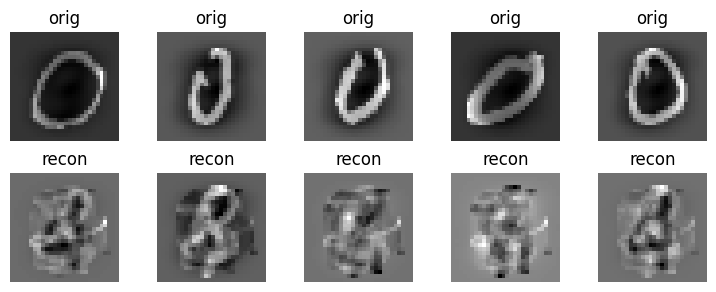

Label not-a の例 (pseudo-inverse recon)


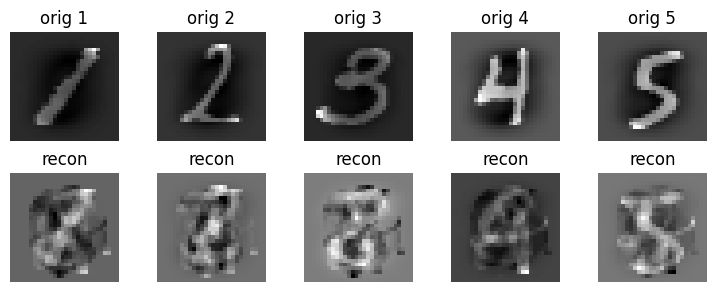

[anchor_local_leak] dataset=mnist, F_type=svd, dim=15, spill_num=10, a_label=0
  pseudo-inverse ACC   : all=0.5280, a=0.5612, not-a=0.5244
  MLP recon ACC        : all=0.1340, a=0.0510, not-a=0.1430
Label a = 0 の例 (pseudo-inverse recon)


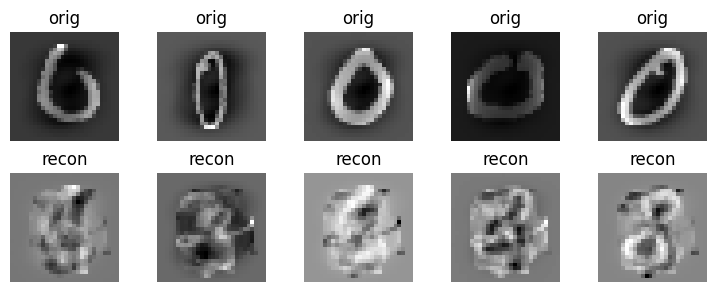

Label not-a の例 (pseudo-inverse recon)


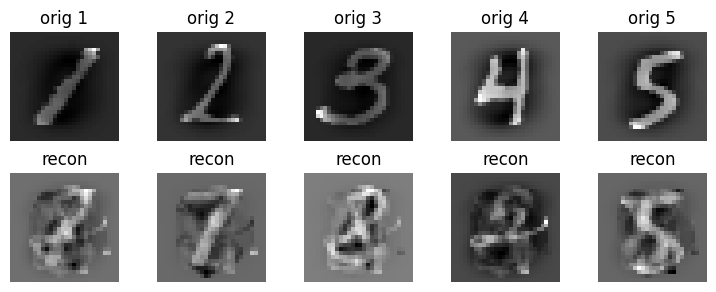

[anchor_local_leak] dataset=mnist, F_type=ae, dim=15, spill_num=10, a_label=0
  pseudo-inverse ACC   : all=0.5150, a=0.3878, not-a=0.5288
  MLP recon ACC        : all=0.1230, a=0.0408, not-a=0.1319
Label a = 0 の例 (pseudo-inverse recon)


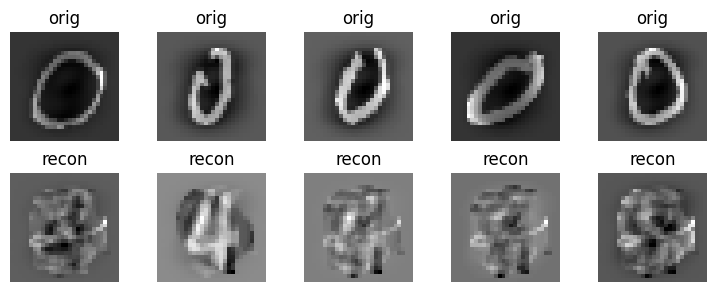

Label not-a の例 (pseudo-inverse recon)


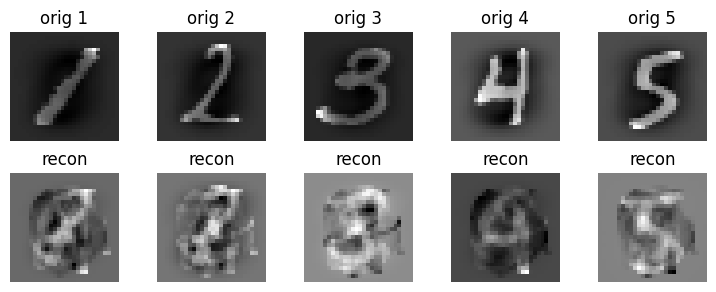

[anchor_local_leak] dataset=mnist, F_type=kernel_pca_self_tuning, dim=15, spill_num=10, a_label=0
  pseudo-inverse ACC   : all=0.5900, a=0.8163, not-a=0.5654
  MLP recon ACC        : all=0.1320, a=0.2245, not-a=0.1220
UMAP seed: 3


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Label a = 0 の例 (pseudo-inverse recon)


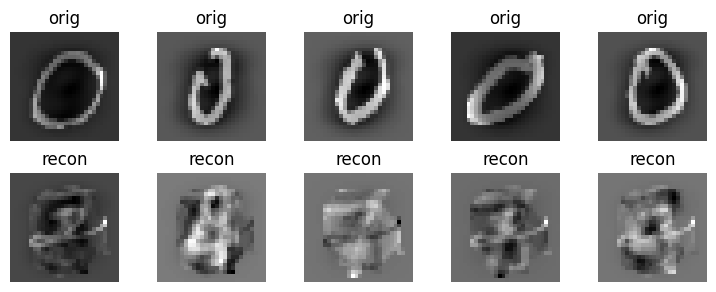

Label not-a の例 (pseudo-inverse recon)


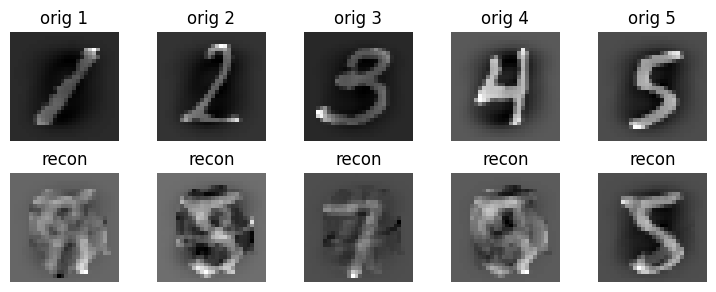

[anchor_local_leak] dataset=mnist, F_type=umap, dim=15, spill_num=10, a_label=0
  pseudo-inverse ACC   : all=0.1680, a=0.0204, not-a=0.1840
  MLP recon ACC        : all=0.0730, a=0.0816, not-a=0.0721


,name,dataset,spill_type,y_name,num_institution_user,data_distribution,anchor_method,num_anchor_data,dim_intermediate,spill_num,...,inter_normalization,smote_ratio,gamma_ratio,seed,acc_pinv,acc_pinv_a,acc_pinv_not_a,acc_mlp,acc_mlp_a,acc_mlp_not_a
0,tutorial_mnist,mnist,even,target,1000,even,smote,1000,15,10,...,True,0.8,1.0,3,0.528,0.561224,0.524390,0.134,0.051020,0.143016
1,tutorial_mnist,mnist,even,target,1000,even,smote,1000,15,10,...,True,0.8,1.0,3,0.515,0.387755,0.528825,0.123,0.040816,0.131929
2,tutorial_mnist,mnist,even,target,1000,even,smote,1000,15,10,...,True,0.8,1.0,3,0.590,0.816327,0.565410,0.132,0.224490,0.121951
3,tutorial_mnist,mnist,even,target,1000,even,smote,1000,15,10,...,True,0.8,1.0,3,0.168,0.020408,0.184035,0.073,0.081633,0.072062


In [42]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["even"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"],
    "num_anchor_data": [1000],
    "dim_intermediate": [15],
    "spill_num": [10],
    "F_type": ["svd", "ae", "kernel_pca_self_tuning", "umap"], #  "ae", "kernel_pca_self_tuning", , "supervised_umap"
    "inter_normalization": [True],
    "smote_ratio": [0.8],
    "gamma_ratio": [1.0],
    "seed":[3]
}
df_results = run_anchor_local_leak_grid(base_config_dict)
df_results

In [ ]:
import os
print(os.getcwd())

c:\Users\sueya\Git-Repositories\takano_labo\dca
